<a href="https://colab.research.google.com/github/TimL52/TimL52/blob/main/PyTorch_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch Tutorial

References:
- https://playground.tensorflow.org/
- Quickstart: https://pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html
- Linear / fully-connected layers: https://pytorch.org/docs/main/nn.html#linear-layers
  - [`torch.nn.Linear`](https://pytorch.org/docs/main/generated/torch.nn.Linear.html)
- Activation functions: found in https://pytorch.org/docs/main/nn.functional.html
- Loss functions: https://pytorch.org/docs/main/nn.html#loss-functions
  - [`torch.nn.BCELoss`](https://pytorch.org/docs/main/generated/torch.nn.BCELoss.html)
  - [`torch.nn.CrossEntropyLoss`](https://pytorch.org/docs/main/generated/torch.nn.CrossEntropyLoss.html)


In [56]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from tqdm import tqdm

In [57]:
%config InlineBackend.figure_formats = ['svg']

In [58]:
import torch
from torch import nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [59]:
#@title Run this code block to define plotting helper functions
#@markdown This defines `plot_boundary(X, pred)` which can plot the decision boundary of a neural network
from matplotlib import cm, ticker

MARKERS = ['o', 'v', '+']
COLORS = ['red', 'green', 'blue']
rgb_gradient_cmap = matplotlib.colors.ListedColormap(COLORS)
red_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("RedGradient", [(1, 0, 0, 0), (1, 0, 0, 1)])  # Transparent to red
green_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("GreenGradient", [(0, 1, 0, 0), (0, 1, 0, 1)])  # Transparent to green
blue_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("BlueGradient", [(0, 0, 1, 0), (0, 0, 1, 1)])  # Transparent to blue

def plot_points(X, y):
    for i, label in enumerate(set(y)):
        points = X[y == label]
        marker = MARKERS[i % len(MARKERS)]
        color = COLORS[i % len(COLORS)]
        plt.scatter(points[:,0], points[:,1], marker=marker, color=color)

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

def predict(model, x):
    with torch.no_grad():
        o = net(torch.from_numpy(x).float())
    return o.numpy()

def plot_boundary(X, pred, num_classes=2):
    # Define grid limits based on current plot or data
    try:
        x_min, x_max = plt.gca().get_xlim()
        y_min, y_max = plt.gca().get_ylim()
    except:
        x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
        y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1

    # Generate mesh grid
    xs, ys = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )
    xys = np.column_stack([xs.ravel(), ys.ravel()])

    # Make predictions over the grid points
    try:
        zs = pred(xys)
        if num_classes == 2:
            # Binary case: plot boundary based on probability threshold 0.5
            zs = zs.reshape(xs.shape)
            plt.contour(xs, ys, (zs >= 0.5).astype(int), colors='grey')
            plt.imshow(zs, cmap="PiYG", vmin=-0.2, vmax=1.2, alpha=0.4, origin='lower', extent=[x_min, x_max, y_min, y_max])
        else:
            # Multi-class case: color - gradient for each
            zzs = np.exp(zs) / np.sum(np.exp(zs), axis=1, keepdims=True)
            Z1 = zzs[:, 0].reshape(xs.shape)
            Z2 = zzs[:, 1].reshape(xs.shape)
            Z3 = zzs[:, 2].reshape(xs.shape)
            plt.imshow(Z1, cmap=red_cmap, origin='lower', alpha=0.6, extent=[x_min, x_max, y_min, y_max])
            plt.imshow(Z2, cmap=green_cmap, origin='lower', alpha=0.6, extent=[x_min, x_max, y_min, y_max])
            plt.imshow(Z3, cmap=blue_cmap, origin='lower', alpha=0.6, extent=[x_min, x_max, y_min, y_max])

            # Multi-class case: boundary - take the argmax over classes
            zs = np.argmax(zs, axis=1).reshape(xs.shape)
            plt.contour(xs, ys, zs, levels=np.arange(num_classes), colors='grey')

            # plt.imshow(zs, cmap=rgb_gradient_cmap, alpha=0.4, origin='lower', extent=[x_min, x_max, y_min, y_max])

    except Exception as e:
        print(f"Error in plotting decision boundary: {e}")
        zs = pred(xys)
        plt.contour(xs, ys, zs.reshape(xs.shape), colors='grey')

    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.title("Decision Boundary")

In [60]:
#@title Run this code block to define datasets
#@markdown - `D1(N)`: binary classificaiton, linear decision boundary
#@markdown - `D2(N)`: binary classificaiton, non-linear decision boundary
#@markdown - `D3(N)`: multiclass classification

class D1(Dataset):
    def __init__(self, N=50):
        super().__init__()
        rng = np.random.default_rng(0)
        self.X = np.r_[2.0 * rng.standard_normal((N//2, 2)) - [2, 2], 2.0 * rng.standard_normal((N//2, 2)) + [2, 2]]
        self.y = np.array([0] * (N//2) + [1] * (N//2))

    def __getitem__(self, idx):
        return torch.from_numpy(self.X[idx]).float(), torch.tensor([self.y[idx]]).float()

    def __len__(self):
        return len(self.X)


class D2(Dataset):
    def __init__(self, N=50):
        super().__init__()
        rng = np.random.default_rng(0)
        X = 3.0 * rng.standard_normal((N, 2))
        y = np.array([0] * N)
        y[np.diag(X@X.T)>10] = 1
        self.X = X
        self.y = y

    def __getitem__(self, idx):
        return torch.from_numpy(self.X[idx]).float(), torch.tensor([self.y[idx]]).float()

    def __len__(self):
        return len(self.X)


class D3(Dataset):
    def __init__(self, N=50):
        super().__init__()
        rng = np.random.default_rng(0)
        X = 3.0 * rng.standard_normal((N, 2))
        y = np.array([0] * N)
        y[np.diag(X@X.T) < 6] = 1
        y[(np.diag(X@X.T) >= 6) & (X@np.array([1,2]) >= 0)] = 2
        self.X = X
        self.y = y

    def __getitem__(self, idx):
        return torch.from_numpy(self.X[idx]).float(), torch.tensor(self.y[idx]).long()

    def __len__(self):
        return len(self.X)

## Backprop demo

Linear regression with mean squared error loss

$$ \widehat{y} = w x + b, \; \; L = \frac{1}{2} (\widehat{y} - y)^2 $$

$$\frac{\partial L}{\partial w} = (\widehat{y} - y) x, \;\; \frac{\partial L}{\partial b} = (\widehat{y} - y)$$

We apply SGD with learning rate = 0.1
- Initialize $w = [0,0], b = 0$.
- The point we use to update is $x=[1,2], y=1$.
- $\widehat{y} = ?$, the updated $w = ?, b = ?$


In [61]:
net = nn.Sequential(nn.Linear(2, 1))
optimizer = torch.optim.SGD(net.parameters(), lr=0.1)

In [62]:
# Initialize and clear gradients
nn.init.zeros_(net[0].weight)
nn.init.zeros_(net[0].bias)
try:
    net[0].weight.grad.zero_()
    net[0].bias.grad.zero_()
except:
    pass

print('Initial parameters')
print('w =', net[0].weight.data)
print('b =', net[0].bias.data)

# Forward pass
x = torch.tensor([1,2]).float()
y_true = torch.tensor([1]).float() #Get prediction of network
y_hat = net(x)  # <-- FILL IN THIS LINE
loss =  1/2*F.mse_loss(y_hat, y_true)  # <-- write loss function
print()
print('Forward pass')
print('y_hat =', y_hat.data)
print('loss. =', loss.data)

# Backward pass
loss.backward()          # <-- FILL IN THIS LINE
print()
print('Gradients')
print('dw =', net[0].weight.grad)
print('db =', net[0].bias.grad)

# Update
optimizer.step() # <-- FILL IN THIS LINE
print()
print('Updated parameters')
print('w =', net[0].weight.data)
print('b =', net[0].bias.data)

Initial parameters
w = tensor([[0., 0.]])
b = tensor([0.])

Forward pass
y_hat = tensor([0.])
loss. = tensor(0.5000)

Gradients
dw = tensor([[-1., -2.]])
db = tensor([-1.])

Updated parameters
w = tensor([[0.1000, 0.2000]])
b = tensor([0.1000])


## Neural Net Training - Example (Logistic Regression)

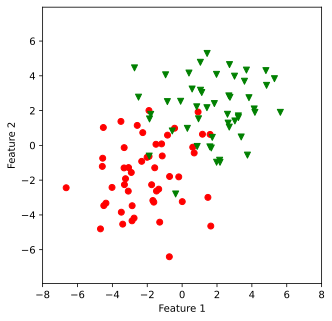

In [63]:
d1 = D1(100)
plt.figure(figsize=(5,5))
plot_points(d1.X, d1.y)
plt.axis('equal')
plt.xlim(-8, 8)
plt.ylim(-8, 8)
plt.show()

### Define the neural network

In [64]:
class Net1(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: put neural net structure here
        self.fc=nn.Linear(2,1)

    def forward(self, x):
        # TODO: define the forward pass here
        z=self.fc(x)
        return torch.sigmoid(z)

In [65]:
torch.random.manual_seed(2)
net = Net1()

In [66]:
# How many float-valued parameters are there?
print('Number of learnable float-valued parameters', count_parameters(net))
print('Neural net architecture:')
print(net)

Number of learnable float-valued parameters 3
Neural net architecture:
Net1(
  (fc): Linear(in_features=2, out_features=1, bias=True)
)


### Before training...

In [67]:
# What are the parameter values before training?
for name, param in net.named_parameters():
    print(name, '\t', param.data)

fc.weight 	 tensor([[ 0.1622, -0.1683]])
fc.bias 	 tensor([0.1939])


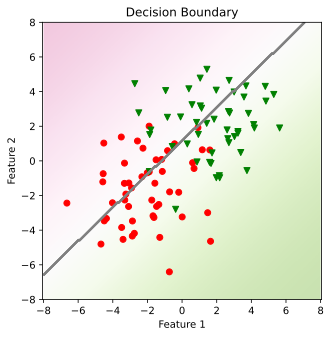

In [68]:
# Where is the decision boundary before training?
plt.figure(figsize=(5,5))
plot_points(d1.X, d1.y)
plt.axis('equal')
plt.xlim(-8, 8)
plt.ylim(-8, 8)
plot_boundary(d1.X, lambda x: predict(net, x))
plt.show()

### Train!

In [69]:
# Training set, loss function, and optimization algorithm
dataloader = DataLoader(d1, batch_size=4)
criterion = nn.BCELoss()
optimizer = torch.optim.SGD(net.parameters(), lr=0.1)

In [84]:
# Trainer loop
for epoch in tqdm(range(1000)):
    for X, y in dataloader:
        optimizer.zero_grad()
        output = net(X)
        loss=criterion(output)
        loss.backward()
        optimizer.step()

  0%|          | 0/1000 [00:00<?, ?it/s]


TypeError: CrossEntropyLoss.forward() missing 1 required positional argument: 'target'

### After training...

In [77]:
# What are the parameter values before training?
for name, param in net.named_parameters():
    print(name, '\t', param.data)

fc1.weight 	 tensor([[ 0.3643, -0.3121],
        [-0.1371,  0.3319],
        [-0.6657,  0.4241],
        [-0.1455,  0.3597]])
fc1.bias 	 tensor([ 0.0983, -0.0866,  0.1961,  0.0349])
fc2.weight 	 tensor([[ 0.1826, -0.1949, -0.0365, -0.0450]])
fc2.bias 	 tensor([0.0725])


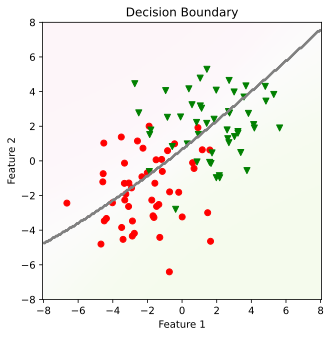

In [76]:
# Where is the decision boundary after training?
plt.figure(figsize=(5,5))
plot_points(d1.X, d1.y)
plt.axis('equal')
plt.xlim(-8, 8)
plt.ylim(-8, 8)
plot_boundary(d1.X, lambda x: predict(net, x))
plt.show()

## Exercise Q2: non-linear decision boundary

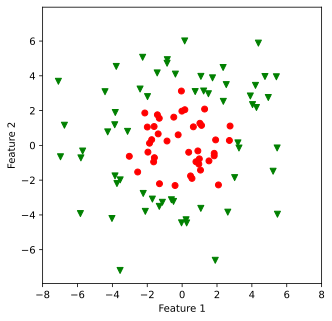

In [75]:
# Data
d2 = D2(100)
plt.figure(figsize=(5,5))
plot_points(d2.X, d2.y)
plt.axis('equal')
plt.xlim(-8, 8)
plt.ylim(-8, 8)
plt.show()

In [74]:
# Model
class Net2(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: put neural net structure here
        self.fc1=nn.Linear(2,4)  #fc stands for forward connect, neural network
        self.fc2=nn.Linear(4,1)

    def forward(self, x):
        # TODO: define the forward pass here
        z = self.fc1(x)
        z= F.tanh(z)
        z=self.fc2(z)
        return torch.sigmoid(z)

torch.random.manual_seed(1)
net = Net2()

print('Number of learnable float-valued parameters', count_parameters(net))
print('Neural net architecture:')
print(net)

Number of learnable float-valued parameters 17
Neural net architecture:
Net2(
  (fc1): Linear(in_features=2, out_features=4, bias=True)
  (fc2): Linear(in_features=4, out_features=1, bias=True)
)


In [ ]:
# What are the parameter values before training?
for name, param in net.named_parameters():
    print(name, '\t', param.data)

# Where is the decision boundary before training?
plt.figure(figsize=(5,5))
plot_points(d2.X, d2.y)
plt.axis('equal')
plt.xlim(-8, 8)
plt.ylim(-8, 8)
plot_boundary(d2.X, lambda x: predict(net, x))
plt.show()

In [ ]:
# Training set, loss function, and optimization algorithm
dataloader=DataLoader(d2,batch_size=4)
criterion = nn.BCELoss()
optimizer = torch.optim.SGD(net.parameters(), lr=0.1)

# Trainer loop
for epoch in tqdm(range(1000)):
  for X,y in dataloader:
    optimizer.zero_grad()
    output=net(X)
    loss=criterion(output,y)
    loss.backward()
    optimizer.step() #same as ex 1

fc.weight 	 tensor([[ 0.1622, -0.1683]])
fc.bias 	 tensor([0.1939])


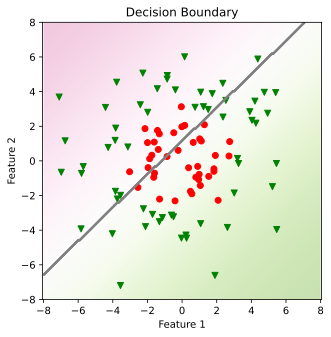

In [73]:
# What are the parameter values after training?
for name, param in net.named_parameters():
    print(name, '\t', param.data)

# Where is the decision boundary after training?
plt.figure(figsize=(5,5))
plot_points(d2.X, d2.y)
plt.axis('equal')
plt.xlim(-8, 8)
plt.ylim(-8, 8)
plot_boundary(d2.X, lambda x: predict(net, x))
plt.show()

## Exercise Q3: three-way classification

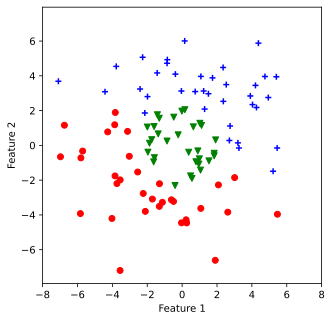

In [88]:
# Data...
d3 = D3(100)
plt.figure(figsize=(5,5))
plot_points(d3.X, d3.y)
plt.axis('equal')
plt.xlim(-8, 8)
plt.ylim(-8, 8)
plt.show()

In [93]:
class Net3(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 4)
        self.fc2 = nn.Linear(4, 3)

    def forward(self, x):
        z = self.fc1(x)
        z = torch.tanh(z)   # better to use torch.tanh instead of F.tanh
        z = self.fc2(z)
        return z


def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)


torch.random.manual_seed(1)
net = Net3()
net.apply(init_weights)

print('Number of learnable float-valued parameters', count_parameters(net))
print('Neural net architecture:')
print(net)


Number of learnable float-valued parameters 27
Neural net architecture:
Net3(
  (fc1): Linear(in_features=2, out_features=4, bias=True)
  (fc2): Linear(in_features=4, out_features=3, bias=True)
)


fc1.weight 	 tensor([[ 0.5435, -0.9776],
        [ 0.6199,  0.2794],
        [ 0.9486,  0.6601],
        [-0.9111, -0.9508]])
fc1.bias 	 tensor([0., 0., 0., 0.])
fc2.weight 	 tensor([[-0.4466,  0.8130, -0.1542,  0.3962],
        [-0.4302,  0.9084, -0.3917,  0.6943],
        [ 0.0110, -0.4877,  0.4759, -0.4914]])
fc2.bias 	 tensor([0., 0., 0.])


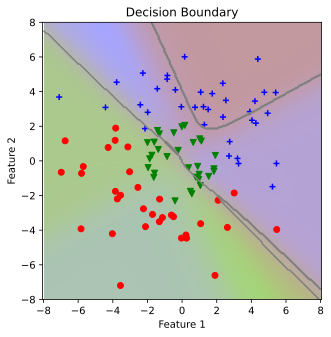

In [94]:
# Before training...

# What are the parameter values before training?
for name, param in net.named_parameters():
    print(name, '\t', param.data)

# Where is the decision boundary before training?
plt.figure(figsize=(5,5))
plot_points(d3.X, d3.y)
plt.axis('equal')
plt.xlim(-8, 8)
plt.ylim(-8, 8)
plot_boundary(d3.X, lambda x: predict(net, x), num_classes=3)
plt.show()

In [95]:
# Train...

# Training set, loss function, and optimization algorithm
dataloader=DataLoader(d3,batch_size=4)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(net.parameters(), lr=0.1)

# Trainer loop
for epoch in range(1000):
  for X,y in dataloader:
    optimizer.zero_grad()
    output=net(X)
    loss=criterion(output,y.long()) #LongTensor
    loss.backward()
    optimizer.step()

fc1.weight 	 tensor([[ 2.3606, -1.0551],
        [ 2.7356,  1.7415],
        [ 0.4463,  2.6914],
        [-1.6249, -4.0384]])
fc1.bias 	 tensor([-5.3760,  6.4605, -6.4162,  1.2473])
fc2.weight 	 tensor([[ 2.9463, -4.9303, -2.3359,  3.1384],
        [-4.9768,  4.6884, -1.5522,  1.7783],
        [ 1.1646,  1.4757,  3.8180, -4.3177]])
fc2.bias 	 tensor([ 1.7084, -3.9089,  2.2005])


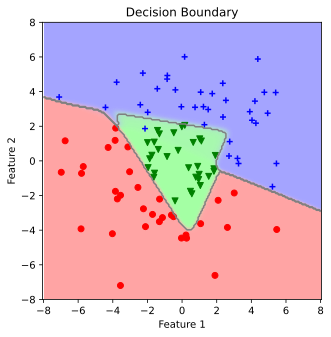

In [96]:
# After training...

# What are the parameter values after training?
for name, param in net.named_parameters():
    print(name, '\t', param.data)

# Where is the decision boundary after training?
plt.figure(figsize=(5,5))
plot_points(d3.X, d3.y)
plt.axis('equal')
plt.xlim(-8, 8)
plt.ylim(-8, 8)
plot_boundary(d3.X, lambda x: predict(net, x), num_classes=3)
plt.show()

## Exercise Q4: Architecture Choices & Effects